# Week 7: Bayesian Reinforcement Learning II

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Belief states, value of information, and uncertainty-aware control*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- define a belief state and a Bayes-adaptive MDP;
- explain dual control: actions can change both the physical state and knowledge;
- compute Bayesian belief updates in a small partially observed problem;
- implement posterior-sampling and optimistic model-based control;
- distinguish aleatoric and epistemic uncertainty;
- use ensemble disagreement as an approximate epistemic diagnostic;
- design an active experiment from posterior predictive uncertainty.

## Repetition: the missing state variable is belief

In an ordinary MDP, $S_t$ is sufficient for predicting the next state given an action. If the transition model $M$ is unknown, the physical state alone is not sufficient. The interaction history

$$
D_t=(S_0,A_0,R_1,S_1,\ldots,S_t)
$$

induces a posterior $p(M\mid D_t)$. A Bayes-adaptive state is therefore

$$
B_t=\bigl(S_t,\,p(M\mid D_t)\bigr).
$$

An action changes the physical system and the information available for later decisions. The corresponding Bellman equation is a value equation on beliefs,

$$
V^*(b)=\max_a\left[r(b,a)+\gamma\sum_o p(o\mid b,a)V^*(\tau(b,a,o))\right],
$$

where $\tau$ is the Bayesian belief update. Exact solution is difficult because the belief space is generally continuous and high-dimensional.

## Example 1: sensing before committing

A hidden binary state $H\in\{L,R\}$ is fixed during an episode. The agent's belief is

$$b=\Pr(H=R).$$

It may commit to $L$ or $R$, receiving $+1$ if correct and $-1$ otherwise, or pay a sensing cost $c$ to obtain an observation that is correct with probability $q$. Bayes' rule gives

$$
\Pr(H=R\mid O=R)=\frac{qb}{qb+(1-q)(1-b)}.
$$

This is a minimal dual-control problem: sensing sacrifices immediate reward but can improve the later terminal action.

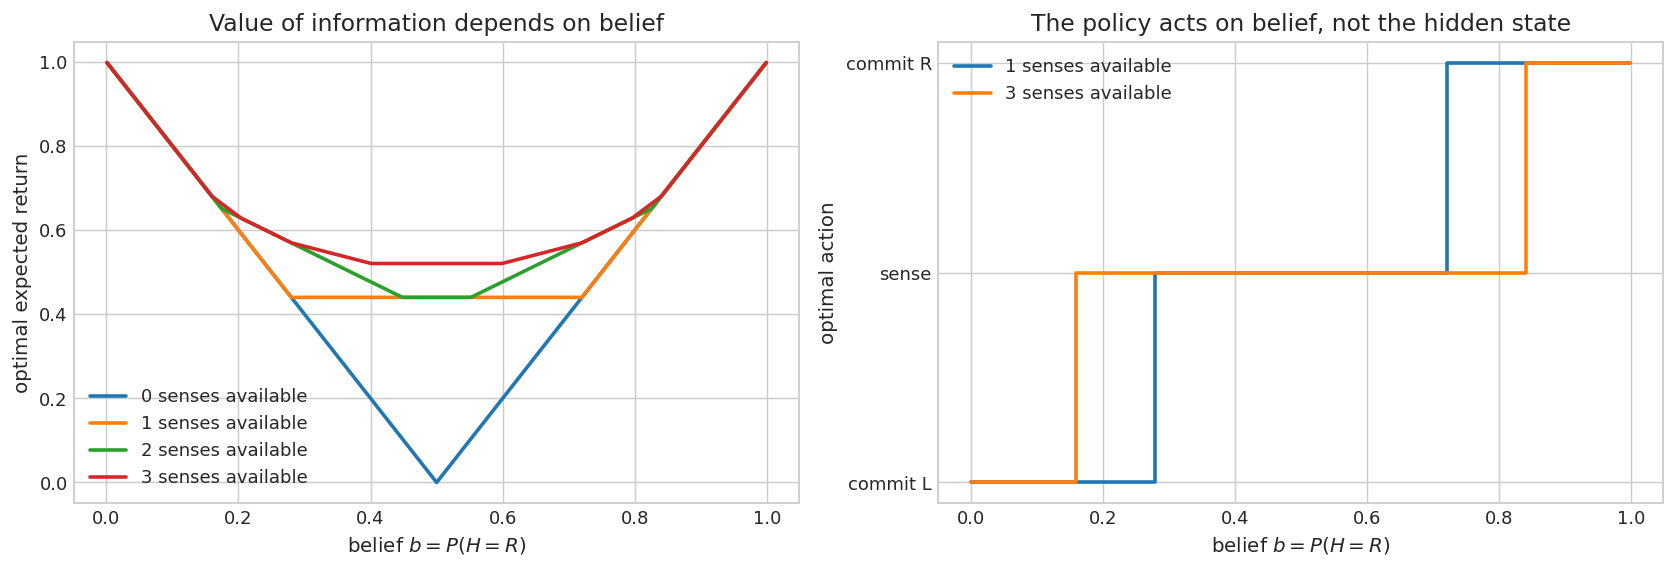

In [2]:
from functools import lru_cache

sensor_accuracy = 0.76
sensing_cost = 0.08

def obs_probability(belief, obs_right):
    q = sensor_accuracy
    return (q * belief + (1 - q) * (1 - belief)) if obs_right else (
        (1 - q) * belief + q * (1 - belief)
    )

def update_belief(belief, obs_right):
    q = sensor_accuracy
    if obs_right:
        return q * belief / obs_probability(belief, True)
    return (1 - q) * belief / obs_probability(belief, False)

def commit_values(belief):
    value_right = 2 * belief - 1
    value_left = 1 - 2 * belief
    return value_left, value_right

def solve_belief(belief, senses_left):
    left, right = commit_values(belief)
    options = {"commit L": left, "commit R": right}
    if senses_left > 0:
        p_r = obs_probability(belief, True)
        b_r = update_belief(belief, True)
        b_l = update_belief(belief, False)
        v_r = solve_belief(b_r, senses_left - 1)[0]
        v_l = solve_belief(b_l, senses_left - 1)[0]
        options["sense"] = -sensing_cost + p_r * v_r + (1 - p_r) * v_l
    action = max(options, key=options.get)
    return options[action], action

beliefs = np.linspace(0.001, 0.999, 401)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
action_to_number = {"commit L": -1, "sense": 0, "commit R": 1}
for budget in [0, 1, 2, 3]:
    values = [solve_belief(float(b), budget)[0] for b in beliefs]
    actions = [action_to_number[solve_belief(float(b), budget)[1]] for b in beliefs]
    axes[0].plot(beliefs, values, lw=2, label=f"{budget} senses available")
    if budget in [1, 3]:
        axes[1].step(beliefs, actions, where="mid", lw=2,
                     label=f"{budget} senses available")
axes[0].set(xlabel=r"belief $b=P(H=R)$", ylabel="optimal expected return",
            title="Value of information depends on belief")
axes[0].legend()
axes[1].set(xlabel=r"belief $b=P(H=R)$", ylabel="optimal action",
            yticks=[-1, 0, 1], yticklabels=["commit L", "sense", "commit R"],
            title="The policy acts on belief, not the hidden state")
axes[1].legend()
plt.tight_layout()
plt.show()

The sensing region is largest near $b=1/2$, where the terminal decision is most uncertain. When the belief is already extreme, more information is unlikely to change the action and therefore has little decision value.

### Simulating belief trajectories

In [3]:
def simulate_episode(true_state, senses_available=3, seed=0):
    local_rng = np.random.default_rng(seed)
    belief = 0.5
    history = []
    for step in range(senses_available + 1):
        value, action = solve_belief(belief, senses_available - step)
        history.append((step, belief, action, value))
        if action != "sense":
            reward = 1 if action[-1] == true_state else -1
            return history, reward
        observation_correct = local_rng.random() < sensor_accuracy
        observed = true_state if observation_correct else ("L" if true_state == "R" else "R")
        belief = update_belief(belief, observed == "R")
    raise RuntimeError("episode did not terminate")

for seed in range(4):
    history, reward = simulate_episode("R", seed=seed)
    print(f"seed={seed}, terminal reward={reward:+d}")
    for step, belief, action, value in history:
        print(f"  step {step}: belief={belief:.3f}, action={action:8s}, value={value:.3f}")

seed=0, terminal reward=+1
  step 0: belief=0.500, action=sense   , value=0.521
  step 1: belief=0.760, action=sense   , value=0.601
  step 2: belief=0.909, action=commit R, value=0.819
seed=1, terminal reward=+1
  step 0: belief=0.500, action=sense   , value=0.521
  step 1: belief=0.760, action=sense   , value=0.601
  step 2: belief=0.500, action=sense   , value=0.440
  step 3: belief=0.760, action=commit R, value=0.520
seed=2, terminal reward=+1
  step 0: belief=0.500, action=sense   , value=0.521
  step 1: belief=0.760, action=sense   , value=0.601
  step 2: belief=0.909, action=commit R, value=0.819
seed=3, terminal reward=+1
  step 0: belief=0.500, action=sense   , value=0.521
  step 1: belief=0.760, action=sense   , value=0.601
  step 2: belief=0.909, action=commit R, value=0.819


## Approximate Bayes-adaptive control with unknown dynamics

Exact belief-state planning is rarely practical. Two important approximations from the lecture are:

**Posterior sampling**

$$
\widetilde M_k\sim p(M\mid D_k),\qquad
\pi_k\in\arg\max_\pi J(\pi;\widetilde M_k).
$$

At the beginning of episode $k$, sample one plausible model and behave optimally for that model. Sampling once per episode produces temporally coherent exploration.

**Optimism**

$$
\widetilde M_k\in\arg\max_{M\in\mathcal C_k}V^*_M,
$$

where $\mathcal C_k$ is a confidence set. An optimistic controller plans under a favorable model that has not yet been ruled out.

The next example uses a corridor with two actions. `walk` is slow and known. `jump` is faster, but its success probability $p$ is unknown. A Beta posterior is carried between episodes. This is a small model-based analogue of uncertain robot dynamics, experimental protocols, or molecular transition models.

In [4]:
class BayesianCorridor:
    # A short episodic control problem with one unknown transition probability.
    def __init__(self, true_jump_probability=0.85, goal=7, seed=0):
        self.true_p = true_jump_probability
        self.goal = goal
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:  # walk
            self.position = min(self.goal, self.position + 1)
            jump_outcome = None
            reward = -0.04
        else:  # jump
            success = self.rng.random() < self.true_p
            self.position = min(self.goal, self.position + 2) if success else max(0, self.position - 1)
            jump_outcome = int(success)
            reward = -0.025 if success else -0.18

        terminal = self.position == self.goal
        if terminal:
            reward += 1.0
        return self.position, reward, terminal, jump_outcome


def solve_corridor(assumed_jump_probability, goal=7, gamma=0.98):
    values = np.zeros(goal + 1)
    for _ in range(500):
        previous = values.copy()
        for state in range(goal):
            walk_state = min(goal, state + 1)
            walk_reward = -0.04 + (1.0 if walk_state == goal else 0.0)
            walk_value = walk_reward + gamma * previous[walk_state] * (walk_state != goal)

            success_state = min(goal, state + 2)
            failure_state = max(0, state - 1)
            success_reward = -0.025 + (1.0 if success_state == goal else 0.0)
            failure_reward = -0.18
            jump_value = assumed_jump_probability * (
                success_reward + gamma * previous[success_state] * (success_state != goal)
            ) + (1 - assumed_jump_probability) * (
                failure_reward + gamma * previous[failure_state]
            )
            values[state] = max(walk_value, jump_value)
        if np.max(np.abs(values - previous)) < 1e-11:
            break

    policy = np.zeros(goal, dtype=int)
    for state in range(goal):
        walk_state = min(goal, state + 1)
        walk_reward = -0.04 + (1.0 if walk_state == goal else 0.0)
        q_walk = walk_reward + gamma * values[walk_state] * (walk_state != goal)
        success_state = min(goal, state + 2)
        failure_state = max(0, state - 1)
        success_reward = -0.025 + (1.0 if success_state == goal else 0.0)
        q_jump = assumed_jump_probability * (
            success_reward + gamma * values[success_state] * (success_state != goal)
        ) + (1 - assumed_jump_probability) * (
            -0.18 + gamma * values[failure_state]
        )
        policy[state] = int(q_jump > q_walk)
    return policy, values

In [5]:
def run_corridor_method(method, episodes=220, seed=0):
    local_rng = np.random.default_rng(seed + 1000)
    env = BayesianCorridor(seed=seed)
    alpha, beta_parameter = 2.0, 2.0
    episode_returns, posterior_means = [], []
    jump_counts, failure_counts = [], []

    for _ in range(episodes):
        posterior_mean = alpha / (alpha + beta_parameter)
        posterior_variance = (
            alpha * beta_parameter /
            ((alpha + beta_parameter)**2 * (alpha + beta_parameter + 1))
        )
        if method == "posterior mean":
            planning_probability = posterior_mean
        elif method == "posterior sampling":
            planning_probability = local_rng.beta(alpha, beta_parameter)
        elif method == "optimism":
            planning_probability = min(1.0, posterior_mean + 1.8 * np.sqrt(posterior_variance))
        else:
            raise ValueError(method)

        policy, _ = solve_corridor(planning_probability, goal=env.goal)
        state = env.reset()
        terminal = False
        total_return = 0.0
        jumps = failures = 0
        while not terminal:
            action = int(policy[state])
            state, reward, terminal, jump_outcome = env.step(action)
            total_return += reward
            if jump_outcome is not None:
                jumps += 1
                alpha += jump_outcome
                beta_parameter += 1 - jump_outcome
                failures += 1 - jump_outcome

        episode_returns.append(total_return)
        posterior_means.append(alpha / (alpha + beta_parameter))
        jump_counts.append(jumps)
        failure_counts.append(failures)

    return {
        "return": np.asarray(episode_returns),
        "posterior_mean": np.asarray(posterior_means),
        "jumps": np.asarray(jump_counts),
        "failures": np.asarray(failure_counts),
    }

corridor_methods = ["posterior mean", "posterior sampling", "optimism"]
corridor_runs = {
    method: [run_corridor_method(method, seed=seed) for seed in range(60)]
    for method in corridor_methods
}

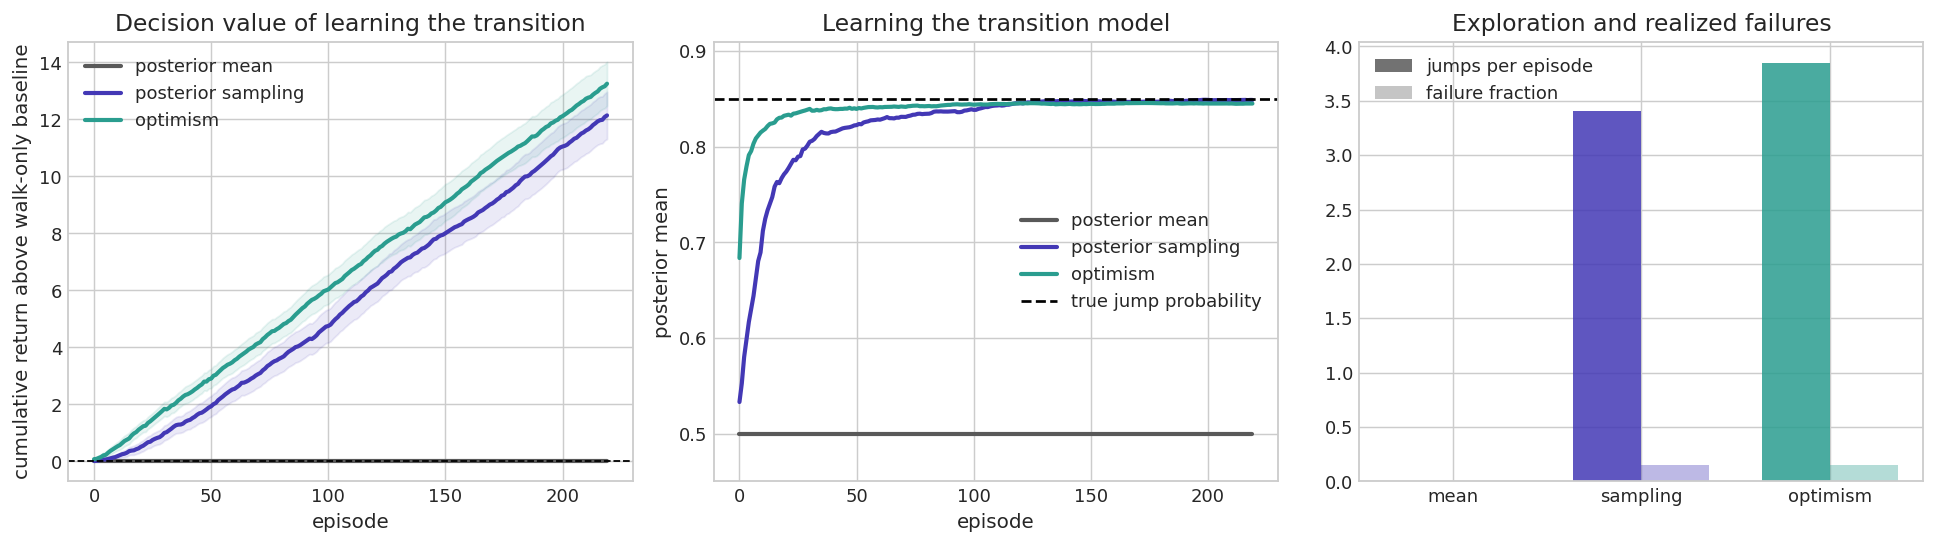

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
colors = {"posterior mean": "0.35", "posterior sampling": UIO_PURPLE,
          "optimism": UIO_GREEN}
episodes = 220
known_walk_return = 1.0 - 7 * 0.04
walk_baseline = known_walk_return * np.arange(1, episodes + 1)

for method in corridor_methods:
    returns = np.stack([run["return"] for run in corridor_runs[method]])
    posterior = np.stack([run["posterior_mean"] for run in corridor_runs[method]])
    cumulative = np.cumsum(returns, axis=1)
    mean_cumulative = cumulative.mean(axis=0)
    sem_cumulative = cumulative.std(axis=0) / np.sqrt(len(cumulative))
    excess_return = mean_cumulative - walk_baseline
    axes[0].plot(excess_return, lw=2.3, color=colors[method], label=method)
    axes[0].fill_between(np.arange(episodes),
                         excess_return - 1.96 * sem_cumulative,
                         excess_return + 1.96 * sem_cumulative,
                         color=colors[method], alpha=0.10)
    axes[1].plot(posterior.mean(axis=0), lw=2.3, color=colors[method], label=method)

axes[0].axhline(0, ls="--", color="black", lw=1)
axes[0].set(xlabel="episode", ylabel="cumulative return above walk-only baseline",
            title="Decision value of learning the transition")
axes[0].legend()
axes[1].axhline(0.85, ls="--", color="black", label="true jump probability")
axes[1].set(xlabel="episode", ylabel="posterior mean",
            ylim=(0.45, 0.91), title="Learning the transition model")
axes[1].legend()

jump_rates, failure_rates = [], []
for method in corridor_methods:
    jumps = np.concatenate([run["jumps"] for run in corridor_runs[method]])
    failures = np.concatenate([run["failures"] for run in corridor_runs[method]])
    jump_rates.append(jumps.mean())
    failure_rates.append(failures.sum() / max(jumps.sum(), 1))
x_positions = np.arange(len(corridor_methods))
axes[2].bar(x_positions - 0.18, jump_rates, width=0.36,
            color=[colors[m] for m in corridor_methods], alpha=0.85,
            label="jumps per episode")
axes[2].bar(x_positions + 0.18, failure_rates, width=0.36,
            color=[colors[m] for m in corridor_methods], alpha=0.35,
            label="failure fraction")
axes[2].set_xticks(x_positions, ["mean", "sampling", "optimism"])
axes[2].set_title("Exploration and realized failures")
axes[2].legend()
plt.tight_layout()
plt.show()

The posterior-mean controller can become self-confirming: if its current mean model recommends the known action, it obtains no data about the uncertain action. Posterior sampling and optimism create structured exploration because a plausible favorable model sometimes makes `jump` optimal. This example is deliberately small, but the same issue appears when an agent chooses experiments, robot trajectories, force-field calculations, or hardware calibrations.

The optimistic controller also illustrates a safety tension: acquiring information through physical interaction can create real failures. Uncertainty-aware control therefore needs both an exploration rule and an explicit constraint or escalation rule.

## Aleatoric and epistemic uncertainty

- **Aleatoric uncertainty** is irreducible randomness conditional on the model, for example detector shot noise or thermal forcing.
- **Epistemic uncertainty** is uncertainty about the model and can in principle be reduced by informative data.

The distinction is operational. Epistemic uncertainty may justify exploration, model refinement, or abstention. Aleatoric uncertainty usually calls for robust or risk-sensitive decisions rather than more data of the same type.

## Example 2: ensemble disagreement as an approximate posterior diagnostic

Deep Bayesian inference is often approximated with ensembles. The following example fits bootstrap polynomial models to data observed only on $x\in[-1,1]$. Disagreement should grow outside the observed region.

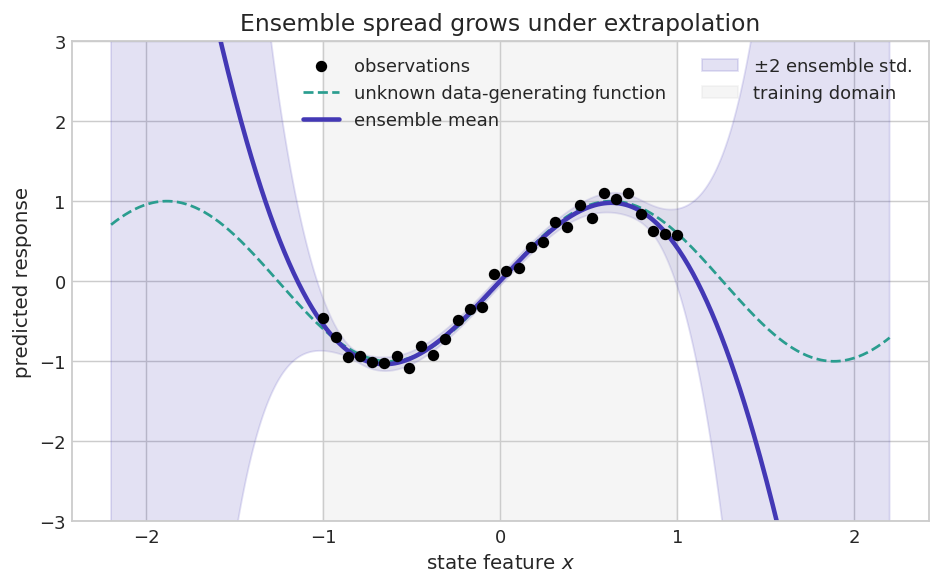

In [7]:
local_rng = np.random.default_rng(24)
x_train = np.linspace(-1, 1, 30)
y_train = np.sin(2.5 * x_train) + 0.10 * local_rng.normal(size=x_train.size)
x_grid = np.linspace(-2.2, 2.2, 500)

predictions = []
for member in range(80):
    index = local_rng.integers(0, len(x_train), len(x_train))
    coefficients = np.polyfit(x_train[index], y_train[index], deg=5)
    predictions.append(np.polyval(coefficients, x_grid))
predictions = np.asarray(predictions)
ensemble_mean = predictions.mean(axis=0)
ensemble_std = predictions.std(axis=0)

plt.scatter(x_train, y_train, s=28, color="black", label="observations", zorder=3)
plt.plot(x_grid, np.sin(2.5 * x_grid), ls="--", color=UIO_GREEN,
         label="unknown data-generating function")
plt.plot(x_grid, ensemble_mean, color=UIO_PURPLE, lw=2.5, label="ensemble mean")
plt.fill_between(x_grid, ensemble_mean - 2 * ensemble_std,
                 ensemble_mean + 2 * ensemble_std, color=UIO_PURPLE,
                 alpha=0.15, label=r"$\pm2$ ensemble std.")
plt.axvspan(-1, 1, color="0.8", alpha=0.18, label="training domain")
plt.ylim(-3, 3)
plt.xlabel("state feature $x$")
plt.ylabel("predicted response")
plt.title("Ensemble spread grows under extrapolation")
plt.legend(ncol=2)
plt.show()

Ensemble spread is not automatically a calibrated posterior standard deviation. It depends on architecture, bootstrap construction, optimization, and data coverage. A model can be uncertain for the wrong reason, or confidently wrong because every ensemble member shares the same misspecification.

### Coverage is an empirical calibration diagnostic

If $\widehat\mu(x)$ and $\widehat\sigma(x)$ were a calibrated Gaussian predictive distribution, the interval

$$
\widehat\mu(x)\pm k\widehat\sigma(x)
$$

would cover the data-generating mean with probability approximately $2\Phi(k)-1$. The following diagnostic compares nominal and empirical coverage separately inside and outside the training domain.

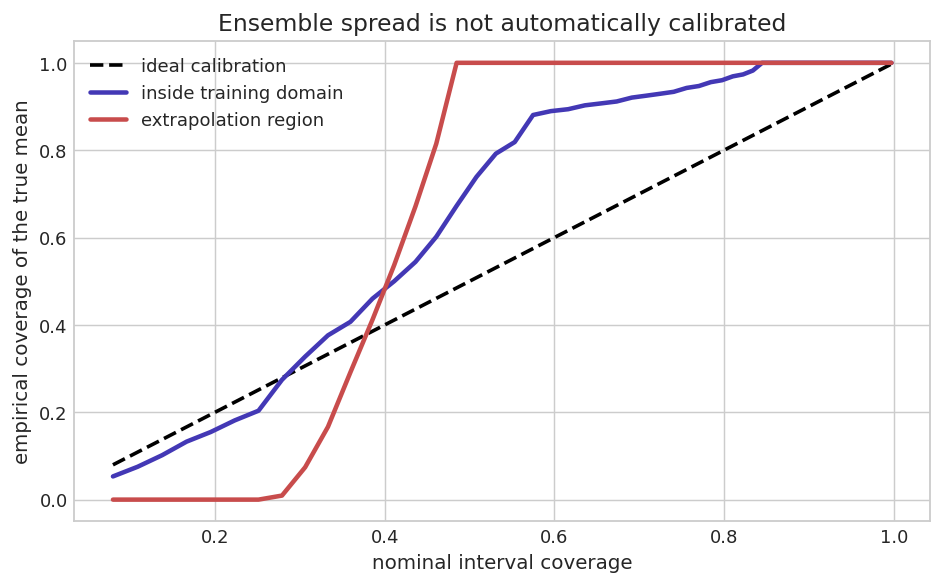

In [8]:
multipliers = np.linspace(0.1, 3.0, 80)
truth_grid = np.sin(2.5 * x_grid)
inside = np.abs(x_grid) <= 1.0
outside = np.abs(x_grid) >= 1.25

def coverage(mask, multiplier):
    lower = ensemble_mean[mask] - multiplier * ensemble_std[mask]
    upper = ensemble_mean[mask] + multiplier * ensemble_std[mask]
    return np.mean((truth_grid[mask] >= lower) & (truth_grid[mask] <= upper))

nominal = 2 * stats.norm.cdf(multipliers) - 1
interpolation_coverage = np.array([coverage(inside, k) for k in multipliers])
extrapolation_coverage = np.array([coverage(outside, k) for k in multipliers])

plt.plot(nominal, nominal, "k--", lw=2, label="ideal calibration")
plt.plot(nominal, interpolation_coverage, color=UIO_PURPLE, lw=2.5,
         label="inside training domain")
plt.plot(nominal, extrapolation_coverage, color=UIO_RED, lw=2.5,
         label="extrapolation region")
plt.xlabel("nominal interval coverage")
plt.ylabel("empirical coverage of the true mean")
plt.title("Ensemble spread is not automatically calibrated")
plt.legend()
plt.show()

Coverage of a deterministic mean function is only one diagnostic; predictive calibration for noisy observations is a different question. Calibration should also be tested under relevant distribution shifts and at the decision thresholds used by the controller.

## Active learning as sequential experiment design

In model-based scientific RL, an action may choose the next simulation or experiment. A Gaussian-process surrogate provides an explicit posterior predictive mean and variance. For training inputs $X$, observations $\mathbf y$, kernel matrix $K$, and a candidate $x_*$,

$$
\mu(x_*)=\mathbf k_*^\top(K+\sigma_n^2I)^{-1}\mathbf y,
$$

$$
\sigma^2(x_*)=k(x_*,x_*)-
\mathbf k_*^\top(K+\sigma_n^2I)^{-1}\mathbf k_*.
$$

A pure uncertainty-sampling rule chooses

$$
x_{t+1}\in\arg\max_x\sigma_t(x).
$$

This is not a complete scientific objective: it ignores cost, safety, and task relevance. It does, however, make the information-allocation mechanism explicit.

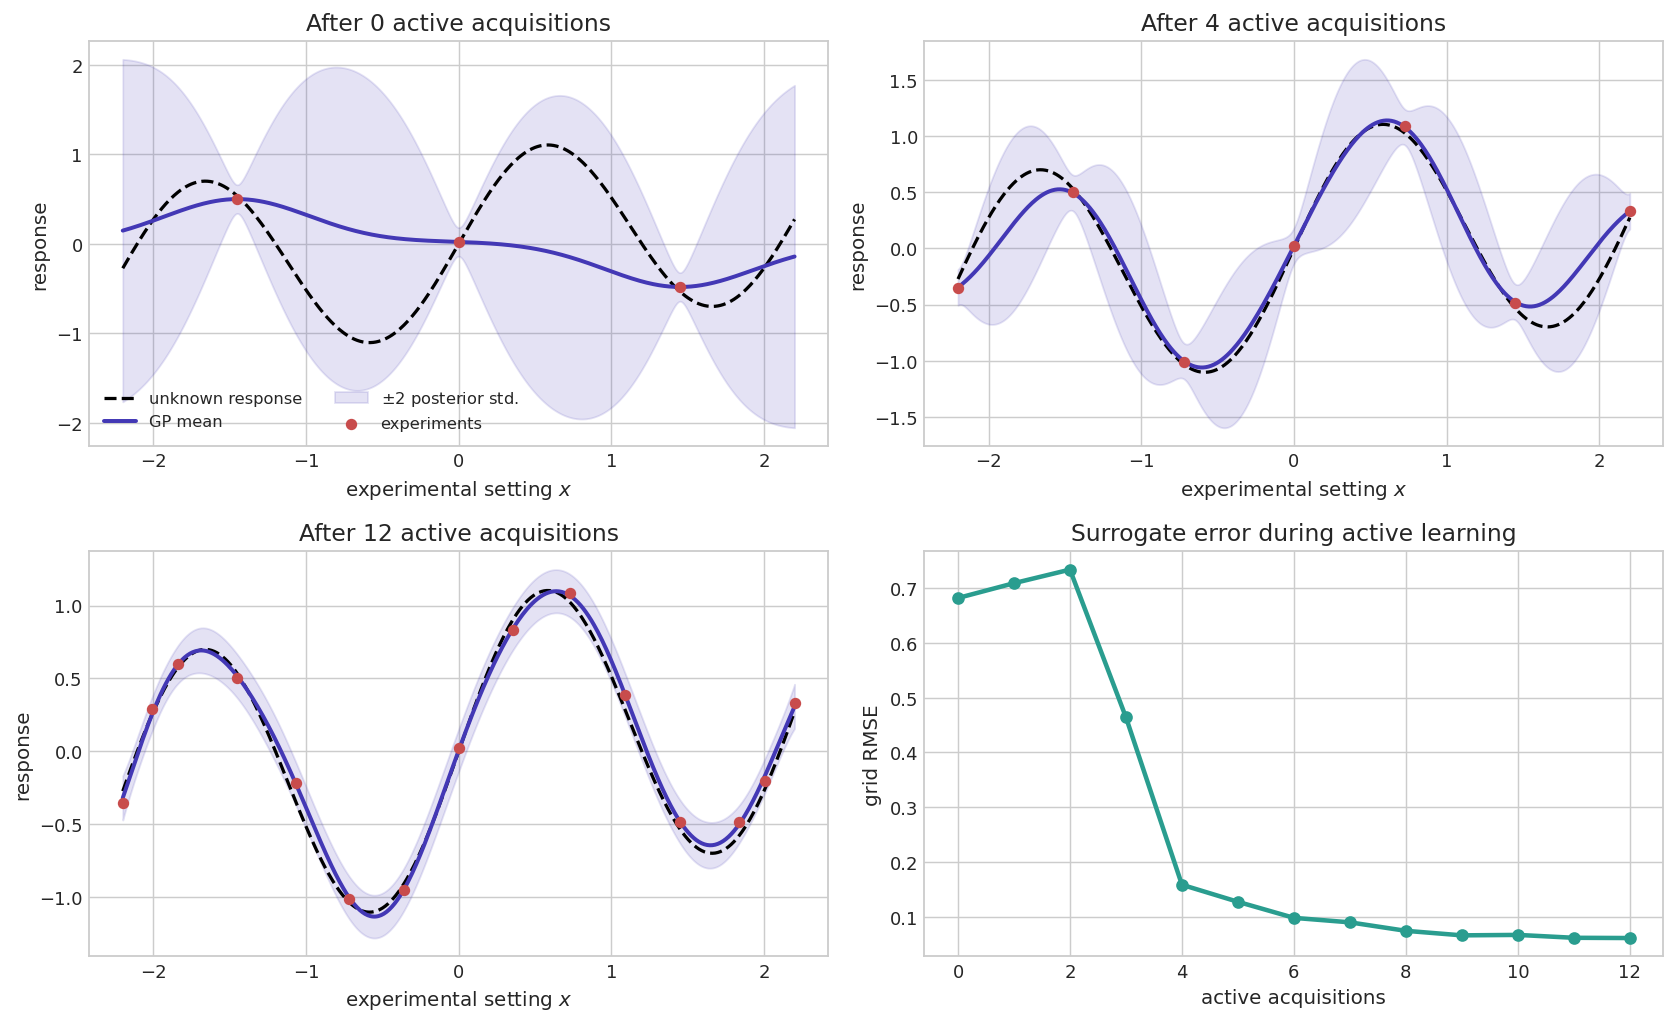

In [9]:
def scientific_response(x_values):
    x_values = np.asarray(x_values)
    return np.sin(2.8 * x_values) + 0.18 * x_values

def rbf_kernel(x_left, x_right, length_scale=0.48, amplitude=1.0):
    x_left = np.asarray(x_left)[:, None]
    x_right = np.asarray(x_right)[None, :]
    return amplitude**2 * np.exp(-0.5 * ((x_left - x_right) / length_scale)**2)

def gp_predict(x_observed, y_observed, x_query, noise_std=0.08):
    K = rbf_kernel(x_observed, x_observed) + noise_std**2 * np.eye(len(x_observed))
    K_cross = rbf_kernel(x_observed, x_query)
    solved_y = np.linalg.solve(K, y_observed)
    mean = K_cross.T @ solved_y
    solved_cross = np.linalg.solve(K, K_cross)
    variance = np.maximum(1e-12, 1.0 - np.sum(K_cross * solved_cross, axis=0))
    return mean, np.sqrt(variance)

acquisition_rng = np.random.default_rng(31)
candidate_grid = np.linspace(-2.2, 2.2, 500)
observed_x = np.array([-1.45, 0.0, 1.45])
observed_y = scientific_response(observed_x) + 0.08 * acquisition_rng.normal(size=3)
snapshots = {}
rmse_history = []

for acquisition_step in range(13):
    gp_mean, gp_std = gp_predict(observed_x, observed_y, candidate_grid)
    rmse_history.append(np.sqrt(np.mean((gp_mean - scientific_response(candidate_grid))**2)))
    if acquisition_step in [0, 4, 12]:
        snapshots[acquisition_step] = (observed_x.copy(), observed_y.copy(),
                                       gp_mean.copy(), gp_std.copy())
    if acquisition_step == 12:
        break
    distance_to_data = np.min(np.abs(candidate_grid[:, None] - observed_x[None, :]), axis=1)
    acquisition_score = gp_std.copy()
    acquisition_score[distance_to_data < 0.035] = -np.inf
    next_x = candidate_grid[np.argmax(acquisition_score)]
    next_y = scientific_response(next_x) + 0.08 * acquisition_rng.normal()
    observed_x = np.append(observed_x, next_x)
    observed_y = np.append(observed_y, next_y)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, step in zip(axes.flat[:3], [0, 4, 12]):
    x_obs, y_obs, mean, std = snapshots[step]
    ax.plot(candidate_grid, scientific_response(candidate_grid), "k--", lw=1.8,
            label="unknown response")
    ax.plot(candidate_grid, mean, color=UIO_PURPLE, lw=2.2, label="GP mean")
    ax.fill_between(candidate_grid, mean - 2 * std, mean + 2 * std,
                    color=UIO_PURPLE, alpha=0.14, label=r"$\pm2$ posterior std.")
    ax.scatter(x_obs, y_obs, color=UIO_RED, s=28, zorder=3, label="experiments")
    ax.set_title(f"After {step} active acquisitions")
    ax.set_xlabel("experimental setting $x$")
    ax.set_ylabel("response")
axes[0, 0].legend(ncol=2, fontsize=9)
axes[1, 1].plot(np.arange(13), rmse_history, marker="o",
                color=UIO_GREEN, lw=2.5)
axes[1, 1].set(xlabel="active acquisitions", ylabel="grid RMSE",
               title="Surrogate error during active learning")
plt.tight_layout()
plt.show()

The acquisition rule spreads experiments through regions that remain uncertain. A task-directed agent might instead maximize expected improvement, expected information about a parameter, reduction in control regret, or discrimination between competing hypotheses. In all cases, the acquisition function is a compressed statement of scientific value and should be audited accordingly.

## Bayesian deep RL and scientific applications

A point-estimate value network stores one parameter vector $\mathbf w$. A Bayesian formulation would maintain

$$
p(\mathbf w\mid D_t),
$$

and posterior predictive action values

$$
p(Q(s,a)\mid D_t)=\int p(Q(s,a)\mid\mathbf w)p(\mathbf w\mid D_t)d\mathbf w.
$$

Exact inference is generally unavailable. Ensembles, dropout approximations, Laplace approximations, and variational methods are practical substitutes, but their uncertainty estimates require calibration checks.

| Domain | Belief state | Informative action | External validation |
|---|---|---|---|
| Quantum calibration | posterior over Hamiltonian and noise parameters | choose pulse and measurement basis | held-out device runs |
| Molecular dynamics | uncertainty over force-field predictions | run an expensive reference calculation | independent configurations and energies |
| Robotics | posterior over friction, mass, and actuator response | safe excitation trajectory | hardware rollout with constraints |
| Experimental science | hypotheses and parameter uncertainty | choose next measurement | preregistered analysis and replication |

The practical goal is not to maximize uncertainty. It is to take actions whose information can improve a later scientific or control decision.

## Problem set

1. Derive both Bayesian updates for the binary sensing problem: $P(H=R\mid O=R)$ and $P(H=R\mid O=L)$.
2. Set the sensing cost to zero. Does the optimal policy always use the complete sensing budget? Explain any boundary cases.
3. Vary the sensor accuracy from $0.5$ to $1.0$ and plot the width of the sensing region. Interpret the result.
4. Replace the symmetric terminal reward by a larger penalty for a false positive. How does the commitment threshold change?
5. Determine the jump-probability threshold at which the optimal corridor policy first uses `jump`. How does the threshold depend on the failure penalty?
6. Replace the optimistic probability by a posterior quantile. Compare return, transition-model error, and failure count.
7. Construct an empirical coverage test for noisy observations rather than the deterministic mean. Why can good average coverage still hide dangerous regional miscalibration?
8. Modify the active-learning acquisition rule to penalize experiments with $|x|>1.5$. Plot the resulting cost-accuracy frontier.

**Mini-project.** Build a Bayesian gridworld with an unknown slip probability and one hazardous region. Compare posterior sampling, optimism, posterior-mean planning, and a chance-constrained controller. Report return, posterior calibration, information acquired, and unsafe transitions over independent seeds.

## Summary

A Bayes-adaptive agent acts on a belief state. Information has value only through its effect on future decisions. Exact planning over beliefs is usually intractable, motivating posterior sampling, optimism, ensembles, learned belief representations, and model-predictive approximations. These methods must distinguish reducible model uncertainty from irreducible stochasticity and must be checked for calibration.

**Further reading:** the supplied Bayesian RL lecture; Duff, *Optimal Learning: Computational Procedures for Bayes-adaptive MDPs*; Osband et al., *Deep Exploration via Bootstrapped DQN*.